<a href="https://colab.research.google.com/github/Saranya0704/Stock-Price-Prediction-Using-Tensorflow/blob/main/stock%20price%20prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install yfinance

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [3]:
# Download Apple stock data
df = yf.download('AAPL', start='2015-01-01', end='2024-01-01')
df = df[['Close']]
print(df.shape)
df.head()

/tmp/ipykernel_5249/3715568646.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('AAPL', start='2015-01-01', end='2024-01-01')
[*********************100%***********************]  1 of 1 completed

(2264, 1)


Price,Close
Ticker,AAPL
Date,
2015-01-02,24.192604
2015-01-05,23.511059
2015-01-06,23.513275
2015-01-07,23.842979
2015-01-08,24.759085


In [4]:
# Scale data between 0 and 1
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

# Create sequences of 60 days to predict next day
X, y = [], []
for i in range(60, len(scaled_data)):
    X.append(scaled_data[i-60:i])
    y.append(scaled_data[i])

X, y = np.array(X), np.array(y)

# Train/test split
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (1763, 60, 1)
X_test shape: (441, 60, 1)


In [6]:
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(60, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.fit(X_train, y_train,
          epochs=20,
          batch_size=32,
          validation_data=(X_test, y_test))

Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 0.0118 - val_loss: 0.0015
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0017 - val_loss: 0.0016
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0014 - val_loss: 0.0014
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0012 - val_loss: 0.0013
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0015 - val_loss: 0.0090
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0010 - val_loss: 0.0018
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 9.1537e-04 - val_loss: 0.0039
Epoch 9/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 9.7567e-04 - val_loss: 0.0019
Epoch 10/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 8.9656e-04 - val_loss: 0.0014
Epoch 11/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 7.3431e-04 - val_loss: 0.0013
Epoch 12/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/

In [8]:
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step


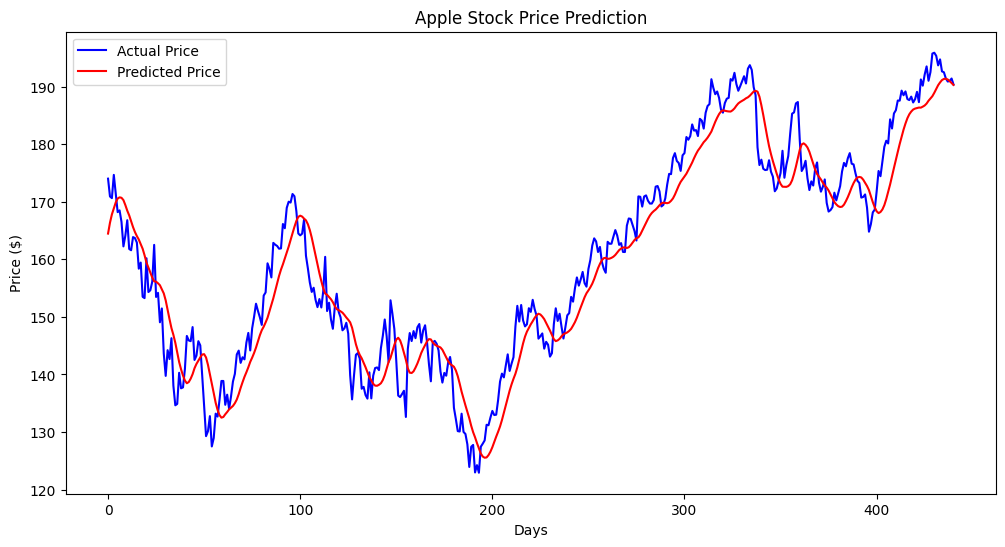

In [9]:
plt.figure(figsize=(12,6))
plt.plot(y_test_actual, label='Actual Price', color='blue')
plt.plot(predictions, label='Predicted Price', color='red')
plt.title('Apple Stock Price Prediction')
plt.xlabel('Days')
plt.ylabel('Price ($)')
plt.legend()
plt.show()

In [10]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test_actual, predictions)
rmse = mse**0.5
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"The model predicts Apple stock price with an average error of ${rmse:.2f}")

MSE: 27.94
RMSE: 5.29
The model predicts Apple stock price with an average error of $5.29
